# 02 — Modeling binary catalyst success with a generalized mixed model

Some screening endpoints are binary: a run reaches a conversion
threshold or it does not. Repeated runs from the same catalyst lot are
correlated, so ordinary logistic regression can understate clustering.
This notebook uses a Bernoulli generalized linear mixed model (GLMM)
with a random lot intercept.

## Learning objectives

You will:

1. generate deterministic clustered binary data;
2. understand log-odds, odds ratios, and random intercepts;
3. fit the supported first-order Laplace Bernoulli GLMM;
4. inspect convergence and conditional predictions;
5. translate fixed effects into illustrative probabilities; and
6. recognize limits of binary screening and Laplace approximation.

## Supported scope used here

PyMixEF's current reference GLMM path supports Bernoulli responses with
the canonical logit link and first-order Laplace integration. This
notebook does not request AGHQ, zero inflation, hurdle likelihoods,
noncanonical links, or distributional submodels.

In [1]:
import importlib
import logging
from pprint import pprint

import numpy as np

import pymixef

# Keep first-run Matplotlib font-cache status out of committed showcase output.
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt = importlib.import_module("matplotlib.pyplot")

print("PyMixEF version:", pymixef.__version__)

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 10,
        "axes.titleweight": "semibold",
    }
)

PyMixEF version: 0.1.1


## 1. Generate repeated binary runs

Twelve catalyst lots each undergo eight activation trials. Every lot is
tested both with and without a promoter. A standardized temperature
score varies by run. Each lot receives a latent random intercept that
shifts its baseline success propensity.

In [2]:
rng = np.random.default_rng(30)

n_lots = 12
runs_per_lot = 8
lot_index = np.repeat(np.arange(n_lots), runs_per_lot)
catalyst_lot = np.array([f"lot-{index + 1:02d}" for index in lot_index])
temperature_scaled = rng.normal(size=lot_index.size)
promoter = np.tile([0, 1, 0, 1, 0, 1, 0, 1], n_lots)

lot_intercept = rng.normal(0.0, 0.45, n_lots)
linear_predictor = -0.30 + 0.55 * temperature_scaled + 0.45 * promoter + lot_intercept[lot_index]
success_probability = 1.0 / (1.0 + np.exp(-linear_predictor))
success = rng.binomial(1, success_probability)

binary_data = {
    "success": success,
    "temperature_scaled": temperature_scaled,
    "promoter": promoter,
    "catalyst_lot": catalyst_lot,
}

print("Rows:", len(success))
print("Observed overall success rate:", round(float(np.mean(success)), 3))
print("Lots:", len(set(catalyst_lot.tolist())))

Rows: 96
Observed overall success rate: 0.531
Lots: 12


Before fitting, compare raw rates by promoter. These are descriptive:
they do not adjust for temperature or lot.

In [3]:
for promoter_value in (0, 1):
    selected = promoter == promoter_value
    print(
        f"promoter={promoter_value}: "
        f"{int(np.sum(success[selected]))}/{int(np.sum(selected))} successes, "
        f"rate={float(np.mean(success[selected])):.3f}"
    )

print("\nFirst eight outcomes:", success[:8].tolist())
print("First eight generating probabilities:", np.round(success_probability[:8], 3))

promoter=0: 20/48 successes, rate=0.417
promoter=1: 31/48 successes, rate=0.646

First eight outcomes: [1, 0, 0, 1, 0, 0, 0, 1]
First eight generating probabilities: [0.677 0.675 0.34  0.551 0.429 0.835 0.344 0.746]


## 2. Specify the Bernoulli logit mixed model

The conditional model is

\[
\operatorname{logit}(P(Y_{ij}=1 \mid b_j)) =
\beta_0 + \beta_T T_{ij} + \beta_P P_{ij} + b_j.
\]

A coefficient is a change in **log odds**, conditional on the lot random
effect. Exponentiating gives a conditional odds ratio. The random
intercept `(1 | catalyst_lot)` accounts for persistent lot quality.

In [4]:
glmm_model = pymixef.Model.from_formula(
    "success ~ temperature_scaled + promoter + (1 | catalyst_lot)",
    family=pymixef.families.Bernoulli(),
)

print(
    glmm_model.explain(
        binary_data,
        engine="glmm",
        method="laplace",
    )
)

Formula: success ~ temperature_scaled + promoter + (1 | catalyst_lot)
Response: success (96 analysis rows)
Fixed design: X(96, 3), rank=3, columns=['Intercept', 'temperature_scaled', 'promoter']
Random designs:
  catalyst_lot: Z(96, 1), groups=12, covariance=unstructured
Excluded source rows: 0
Family: bernoulli (logit link)
Engine: glmm; method: laplace
Compatibility: valid


## 3. Compile and audit

Compilation verifies that the Bernoulli family, Laplace method, formula,
and random-effect design are compatible before optimization starts.

In [5]:
glmm_plan = glmm_model.compile(
    binary_data,
    engine="glmm",
    method="laplace",
    maxiter=400,
)

print(glmm_plan.explain())
pprint(
    {
        "analysis_rows": glmm_plan.matrices.audit.analysis_rows,
        "excluded_rows": glmm_plan.matrices.audit.excluded_rows,
        "fixed_columns": glmm_plan.matrices.fixed_names,
        "random_blocks": len(glmm_plan.matrices.random_blocks),
    }
)

Formula: success ~ temperature_scaled + promoter + (1 | catalyst_lot)
Response: success (96 analysis rows)
Fixed design: X(96, 3), rank=3, columns=['Intercept', 'temperature_scaled', 'promoter']
Random designs:
  catalyst_lot: Z(96, 1), groups=12, covariance=unstructured
Excluded source rows: 0
Family: bernoulli (logit link)
Engine: glmm; method: laplace
Model IR: 4b49e84764dd8116b436851a41479452a20244bfcda666a706c0c6f5fa7ab7bc
Data audit: 96 input, 96 analysis, 0 excluded; reasons={'DATA-RETAINED-001': 96}
{'analysis_rows': 96,
 'excluded_rows': 0,
 'fixed_columns': ('Intercept', 'temperature_scaled', 'promoter'),
 'random_blocks': 1}


## 4. Fit the first-order Laplace model

Laplace approximation integrates over random effects by expanding around
their conditional mode. It is deterministic to numerical tolerance for
this fit, but it is still an approximation.

In [6]:
glmm_fit = glmm_plan.fit()
print(glmm_fit.summary())

PyMixEF fit (laplace, laplace)
Observations: 96
Objective: 59.81036004
Log likelihood: -59.81036004
Convergence: converged
Parameters:
  Intercept                   -0.45711253
  temperature_scaled           0.45127085
  promoter                     1.206127
  sd(catalyst_lot:Intercept)   0.99270959


## 5. Inspect convergence and approximation metadata

GLMMs have an outer parameter optimization and inner conditional-mode
calculations. We require a trustworthy structured convergence report
before interpreting coefficients.

In [7]:
convergence = glmm_fit.convergence
pprint(
    {
        "status": convergence.status,
        "trustworthy": convergence.trustworthy,
        "optimizer_terminated": convergence.optimizer_terminated,
        "scaled_gradient_inf_norm": convergence.scaled_gradient_inf_norm,
        "conditional_mode_failures": convergence.conditional_mode_failures,
        "warning_codes": [warning.code for warning in convergence.warnings],
        "approximation": glmm_fit.extra["approximation"],
        "quadrature_order": glmm_fit.extra["quadrature_order"],
    }
)

assert convergence.trustworthy, "Review convergence before interpretation."
assert convergence.conditional_mode_failures == 0

{'approximation': 'first-order Laplace at the joint conditional mode',
 'conditional_mode_failures': 0,
 'optimizer_terminated': True,
 'quadrature_order': 1,
 'scaled_gradient_inf_norm': 3.126388037363008e-05,
 'status': 'converged',
 'trustworthy': True,
 'warning_codes': []}


## 6. Convert fixed coefficients to conditional odds ratios

`exp(beta)` is an odds ratio at the same lot random effect and with other
predictors held constant. An odds ratio is not a probability ratio and
should not be described as a percent increase in probability.

In [8]:
fixed_effect_names = ["Intercept", "temperature_scaled", "promoter"]
print(f"{'term':24s} {'log-odds':>12s} {'odds ratio':>12s}")
for name in fixed_effect_names:
    estimate = glmm_fit.parameters[name]
    print(f"{name:24s} {estimate:12.4f} {np.exp(estimate):12.4f}")

promoter_odds_ratio = np.exp(glmm_fit.parameters["promoter"])
assert promoter_odds_ratio > 1.0, "The synthetic promoter effect should raise the odds."

print(
    "\nEstimated lot random-intercept SD:",
    round(glmm_fit.parameters["sd(catalyst_lot:Intercept)"], 4),
)

term                         log-odds   odds ratio
Intercept                     -0.4571       0.6331
temperature_scaled             0.4513       1.5703
promoter                       1.2061       3.3405

Estimated lot random-intercept SD: 0.9927


## 7. Illustrate probabilities for an average lot

The next calculation sets the random intercept to zero. These are
**conditional probabilities for a typical lot**, calculated manually
from the fitted fixed effects. They are not fully marginalized
population probabilities, because logistic transformation and random
effect integration do not commute.

In [9]:
def logistic(value):
    return 1.0 / (1.0 + np.exp(-value))


beta0 = glmm_fit.parameters["Intercept"]
beta_temperature = glmm_fit.parameters["temperature_scaled"]
beta_promoter = glmm_fit.parameters["promoter"]

typical_probability_without_promoter = logistic(beta0)
typical_probability_with_promoter = logistic(beta0 + beta_promoter)
assert 0.0 < typical_probability_without_promoter < 1.0
assert typical_probability_without_promoter < typical_probability_with_promoter < 1.0

print(f"{'temperature z':>13s} {'promoter':>10s} {'probability':>13s}")
for temperature_value in (-1.0, 0.0, 1.0):
    for promoter_value in (0, 1):
        eta = beta0 + beta_temperature * temperature_value + beta_promoter * promoter_value
        print(f"{temperature_value:13.1f} {promoter_value:10d} {logistic(eta):13.3f}")

temperature z   promoter   probability
         -1.0          0         0.287
         -1.0          1         0.574
          0.0          0         0.388
          0.0          1         0.679
          1.0          0         0.499
          1.0          1         0.769


### Figure: predicted success probability by promoter state

The fitted curves translate log-odds coefficients into conditional probabilities
for a typical catalyst lot across the observed temperature scale.

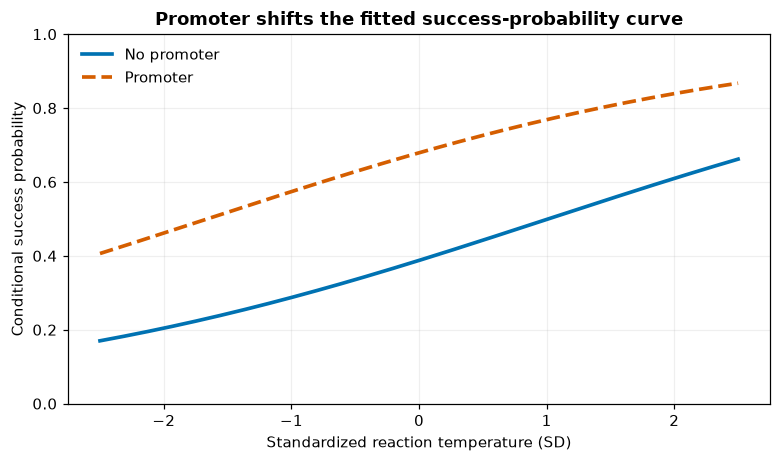

In [10]:
temperature_curve = np.linspace(-2.5, 2.5, 160)
curve_styles = {
    0: ("#0072B2", "-", "No promoter"),
    1: ("#D55E00", "--", "Promoter"),
}

fig, ax = plt.subplots(figsize=(7.2, 4.3))
for promoter_value, (color, line_style, label) in curve_styles.items():
    probability_curve = logistic(
        beta0 + beta_temperature * temperature_curve + beta_promoter * promoter_value
    )
    ax.plot(
        temperature_curve,
        probability_curve,
        color=color,
        linestyle=line_style,
        linewidth=2.4,
        label=label,
    )
ax.set_xlabel("Standardized reaction temperature (SD)")
ax.set_ylabel("Conditional success probability")
ax.set_ylim(0.0, 1.0)
ax.set_title("Promoter shifts the fitted success-probability curve")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

**Interpretation.** Across the displayed temperature range, promoter use shifts the
conditional success probability upward for a lot with random intercept zero. These
curves are conditional illustrations rather than fully marginalized probabilities.

## 8. Inspect lot modes and conditional calibration

Estimated random effects are conditional modes, not direct observations
of permanent lot quality. Ranking them is descriptive and subject to
shrinkage and uncertainty.

Conditional fitted probabilities use those modes. The calibration table
below summarizes the same analysis data and is **not** out-of-sample
validation.

In [11]:
sorted_lot_modes = sorted(
    glmm_fit.random_effects.items(),
    key=lambda item: item[1],
)
assert all(np.isfinite(mode) for _, mode in sorted_lot_modes)
print("Three lowest conditional lot modes:")
pprint(sorted_lot_modes[:3])
print("Three highest conditional lot modes:")
pprint(sorted_lot_modes[-3:])

fitted_probability = np.asarray(glmm_fit.fitted_values)
assert np.all(np.isfinite(fitted_probability))
assert np.all((fitted_probability > 0.0) & (fitted_probability < 1.0))
bin_edges = np.array([0.0, 0.35, 0.50, 0.65, 1.01])
bin_index = np.digitize(fitted_probability, bin_edges) - 1
print("\nIn-sample conditional calibration:")
for index in range(len(bin_edges) - 1):
    selected = bin_index == index
    if np.any(selected):
        print(
            f"[{bin_edges[index]:.2f}, {bin_edges[index + 1]:.2f}): "
            f"n={int(np.sum(selected)):2d}, "
            f"mean predicted={float(np.mean(fitted_probability[selected])):.3f}, "
            f"observed={float(np.mean(success[selected])):.3f}"
        )

Three lowest conditional lot modes:
[('catalyst_lot[lot-02].Intercept', -1.3049633642575238),
 ('catalyst_lot[lot-03].Intercept', -0.8457632027585456),
 ('catalyst_lot[lot-01].Intercept', -0.5978208873556243)]
Three highest conditional lot modes:
[('catalyst_lot[lot-08].Intercept', 0.7617827765341691),
 ('catalyst_lot[lot-10].Intercept', 0.9357991471910676),
 ('catalyst_lot[lot-11].Intercept', 1.4327743503199881)]

In-sample conditional calibration:
[0.00, 0.35): n=23, mean predicted=0.250, observed=0.261
[0.35, 0.50): n=22, mean predicted=0.421, observed=0.318
[0.50, 0.65): n=16, mean predicted=0.578, observed=0.438
[0.65, 1.01): n=35, mean predicted=0.766, observed=0.886


### Figure: catalyst-lot conditional modes

The caterpillar view makes lot-to-lot heterogeneity and shrinkage around zero easier
to inspect than a printed list alone.

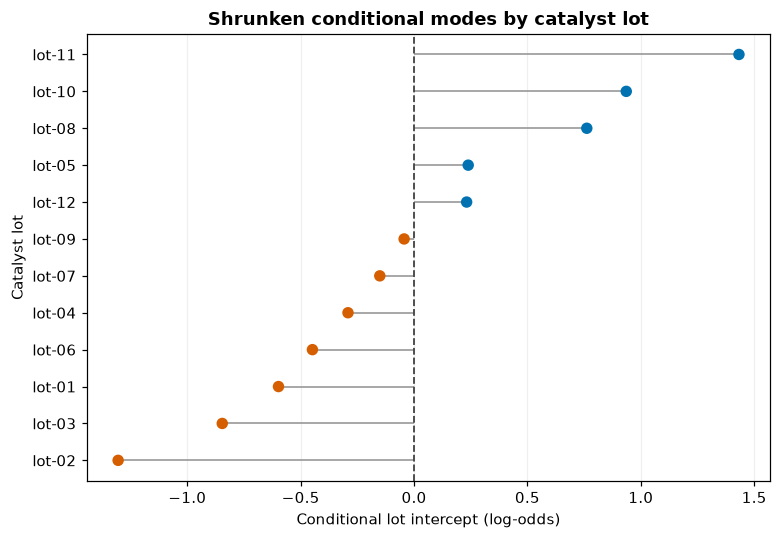

In [12]:
mode_names = [name.split("[", 1)[1].split("]", 1)[0] for name, _ in sorted_lot_modes]
mode_values = np.array([value for _, value in sorted_lot_modes])
mode_positions = np.arange(len(mode_values))

fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.hlines(
    mode_positions,
    0.0,
    mode_values,
    color="#999999",
    linewidth=1.1,
)
ax.scatter(
    mode_values,
    mode_positions,
    c=np.where(mode_values >= 0.0, "#0072B2", "#D55E00"),
    s=42,
    zorder=3,
)
ax.axvline(0.0, color="#444444", linewidth=1.2, linestyle="--")
ax.set_yticks(mode_positions, labels=mode_names)
ax.set_xlabel("Conditional lot intercept (log-odds)")
ax.set_ylabel("Catalyst lot")
ax.set_title("Shrunken conditional modes by catalyst lot")
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
plt.show()

**Interpretation.** Lots vary around the population intercept, with conditional
modes pulled toward zero by the mixed model. The points are model-based estimates,
not permanent quality scores for ranking future lots.

### Figure: in-sample conditional calibration

Each point compares the mean conditional fitted probability with the observed
success fraction in one probability bin; labels give the bin sample size.

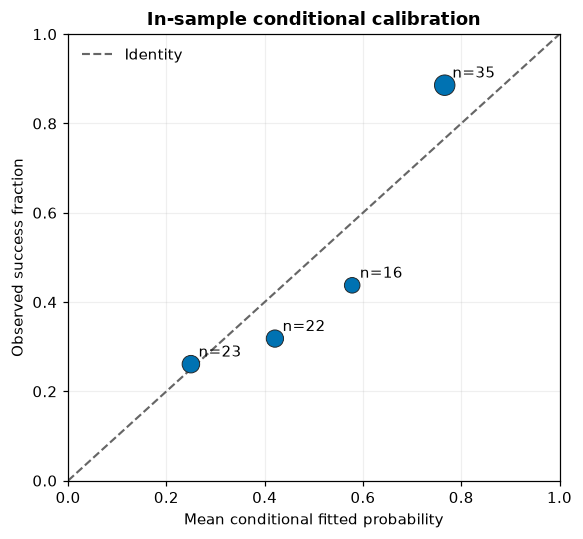

In [13]:
calibration_predicted = []
calibration_observed = []
calibration_count = []
for index in range(len(bin_edges) - 1):
    selected = bin_index == index
    if np.any(selected):
        calibration_predicted.append(float(np.mean(fitted_probability[selected])))
        calibration_observed.append(float(np.mean(success[selected])))
        calibration_count.append(int(np.sum(selected)))

fig, ax = plt.subplots(figsize=(5.4, 5.0))
ax.plot(
    [0.0, 1.0],
    [0.0, 1.0],
    color="#666666",
    linestyle="--",
    linewidth=1.4,
    label="Identity",
)
ax.scatter(
    calibration_predicted,
    calibration_observed,
    s=40 + 4 * np.asarray(calibration_count),
    color="#0072B2",
    edgecolor="#222222",
    linewidth=0.6,
    zorder=3,
)
for predicted, observed_rate, count in zip(
    calibration_predicted,
    calibration_observed,
    calibration_count,
    strict=True,
):
    ax.annotate(
        f"n={count}",
        (predicted, observed_rate),
        xytext=(5, 5),
        textcoords="offset points",
    )
ax.set_xlabel("Mean conditional fitted probability")
ax.set_ylabel("Observed success fraction")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_title("In-sample conditional calibration")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

**Interpretation.** Points near the identity line show descriptive agreement on the
analysis data. Because lot modes were estimated from these same outcomes, this is a
diagnostic view rather than out-of-lot validation.

## 9. Reproducibility record

The manifest records the exact model/data fingerprints and declares the
deterministic-tolerance reproducibility class.

In [14]:
manifest = glmm_fit.manifest.to_dict()
pprint(
    {
        "engine": manifest["engine"],
        "method": manifest["method"],
        "model_ir_hash": manifest["model_ir_hash"],
        "data_hash": manifest["data_hash"],
        "reproducibility_class": manifest["reproducibility_class"],
        "optimizer_sequence": manifest["settings"]["optimizer_sequence"],
    }
)

{'data_hash': 'sha256:1aa9c676455ba207bc9ccc70bd9a303b06abf35ed4fdd87ee4a69787c4f72966',
 'engine': 'glmm',
 'method': 'laplace',
 'model_ir_hash': 'sha256:4b49e84764dd8116b436851a41479452a20244bfcda666a706c0c6f5fa7ab7bc',
 'optimizer_sequence': ['L-BFGS-B outer',
                        'Powell outer rescue',
                        'L-BFGS-B outer refinement',
                        'BFGS conditional mode'],
 'reproducibility_class': 'deterministic-with-tolerance'}


## Interpretation

In this synthetic sample, higher standardized temperature and promoter
use both have positive conditional log-odds coefficients. The nonzero
lot standard deviation indicates meaningful clustering after accounting
for those run-level predictors.

The coefficient estimates need not equal the generating values exactly.
Binary sampling, a modest number of lots, shrinkage, and Laplace
approximation all contribute variation.

## Scope note

This showcase deliberately uses the supported Bernoulli-logit first-order
Laplace model and labels its conditional interpretations. A decision
workflow can strengthen it by retaining continuous response information
when available, checking approximation and random-effect assumptions, and
validating on held-out lots so mechanistic claims remain aligned with the
experiment's limitations.

## Exercises

1. Change the promoter generating effect from 0.45 to 0.0. How often
   does a finite sample still produce a nonzero estimate?
2. Increase the lot-intercept SD and inspect shrinkage in lot modes.
3. Replace the binary endpoint with counts and use the supported Poisson
   family, after deciding what the exposure means.
4. Hold out entire lots and compute truly out-of-lot predictive metrics.
5. Deliberately request an unsupported extension and inspect the typed
   refusal instead of attempting to bypass it.

## Takeaways

- Match the response distribution to the scientific endpoint.
- Model repeated runs from the same lot as clustered.
- Interpret log-odds and odds ratios carefully.
- Check both outer and conditional-mode convergence.
- Separate conditional, marginal, in-sample, and out-of-sample claims.